In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
train_path = 'C:/MCA/ai/traffic_light/train'
test_path = 'C:/MCA/ai/traffic_light/test'

In [4]:
#image processing
train_datagen=ImageDataGenerator(rescale=1./255,
                                 rotation_range=20,
                                zoom_range=0.2,
                                width_shift_range=0.2,
)

test_datagen=ImageDataGenerator(rescale=1./255)

In [8]:
# Load dataset
train_generator=train_datagen.flow_from_directory(train_path,
                                                target_size=(64,64),
                                                batch_size=32,
                                                class_mode='categorical')

test_generator=test_datagen.flow_from_directory(test_path,
                                                  target_size=(64,64),
                                                  batch_size=32,
                                                  class_mode='categorical',
                                                  shuffle=False)
print(train_generator.class_indices)


Found 300 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
{'Green': 0, 'Red': 1, 'Yellow': 2}


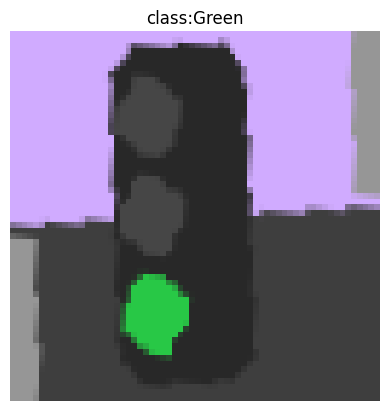

In [9]:
#display one image
image,labels=next(train_generator)
plt.imshow(image[0])
plt.title("class:"+list(train_generator.class_indices.keys())[np.argmax(labels[0])])
plt.axis('off')
plt.show()

In [17]:
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(3,activation='softmax'))

In [18]:
#compile the model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [20]:
# Training the model
model.fit(train_generator,epochs=10,validation_data=test_generator,)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 375ms/step - accuracy: 0.5600 - loss: 0.9794 - val_accuracy: 1.0000 - val_loss: 0.4461
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8433 - loss: 0.4286 - val_accuracy: 1.0000 - val_loss: 0.0306
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9333 - loss: 0.2039 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.9700 - loss: 0.0987 - val_accuracy: 1.0000 - val_loss: 5.9696e-04
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9967 - loss: 0.0332 - val_accuracy: 1.0000 - val_loss: 6.9170e-04
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9867 - loss: 0.0241 - val_accuracy: 1.0000 - val_loss: 2.0466e-05
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9933 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 2.4477e-05
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 1.0000 - loss: 0.0054 - val_ac

In [22]:
losss,acc=model.evaluate(test_generator)
print("Test Accuracy:",acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 1.6693e-05
Test Accuracy: 1.0


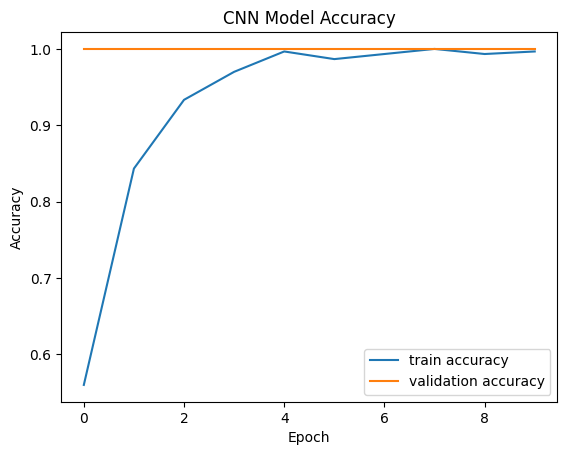

In [23]:
plt.plot(model.history.history['accuracy'],label='train accuracy')
plt.plot(model.history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Model Accuracy')
plt.legend()
plt.show()